# NB02: 서울시 건물 추출 및 층수 정보 통합

**목적**: 경기도 전체 건물 shapefile에서 성남시 건물만 추출하고, 건물 층수 데이터 통합

**입력**: 
- `00_data/(연속수치지형도)건물_경기/N3A_B0010000_41_A.shp` + `_B.shp` (EPSG:5179, ~2.8GB)
- `processed/seongnam_boundary.gpkg` (NB01 출력)
- 건물 층수 데이터 (V-World WFS 또는 건축물대장 → `00_data/추가/building_floors/`)

**출력**: `processed/seongnam_buildings.gpkg`

> **NOTE**: 건물 shapefile에는 층수/높이 필드가 없음. 별도 데이터 필요.  
> 데이터 미확보 시 우선 footprint만 추출하고, 층수는 이후 병합.

In [ ]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

BASE = Path(r"E:\서울시데이터경진대회\Aero-Logic-Seoul")
RAW = BASE / "00_data"
OUT = BASE / "processed"

# 성남시 경계 로드 (EPSG:5179, 거리계산용)
seoul = gpd.read_file(OUT / "seoul_boundary.gpkg", layer="dong_5179")
bounds = seoul.total_bounds  # (minx, miny, maxx, maxy)
print(f"서울시 Bounds (EPSG:5179): {bounds}")

# 약간의 버퍼 추가 (500m)
BBOX = (bounds[0] - 500, bounds[1] - 500, bounds[2] + 500, bounds[3] + 500)
print(f"건물 로드용 bbox (500m 버퍼): {BBOX}")

서울시 Bounds (EPSG:5179): [179189.76163945 536547.40661053 216242.2727258  566863.54149205]
건물 로드용 bbox (500m 버퍼): (np.float64(178689.76163944902), np.float64(536047.406610533), np.float64(216742.2727258006), np.float64(567363.5414920457))


## 1. 건물 shapefile 로드 (bbox 필터로 서울 영역만)

서울시 전체 건물 shapefile이 ~2.8GB이므로, `bbox` 파라미터로 서울 영역만 로드하여 메모리 절약

In [2]:
%%time
# 건물 A + B 파일 로드 (bbox 필터 적용)
bldg_dir = RAW / "F_FAC_BUILDING_서울"

buildings = []

fpath = bldg_dir / f"F_FAC_BUILDING_11_202604.shp"
print(f"로드 중: {fpath.name}...", end=" ")
gdf = gpd.read_file(fpath, bbox=BBOX)
print(f"{len(gdf):,}건")
buildings.append(gdf)

gdf_bldg = pd.concat(buildings, ignore_index=True)
print(f"\nbbox 내 전체 건물: {len(gdf_bldg):,}건")
print(f"컬럼: {gdf_bldg.columns.tolist()}")

로드 중: F_FAC_BUILDING_11_202604.shp... 696,737건

bbox 내 전체 건물: 696,737건
컬럼: ['UFID', 'BLD_NM', 'DONG_NM', 'GRND_FLR', 'UGRND_FLR', 'PNU', 'ARCHAREA', 'TOTALAREA', 'PLATAREA', 'HEIGHT', 'STRCT_CD', 'USABILITY', 'BC_RAT', 'VL_RAT', 'BLDRGST_PK', 'USEAPR_DAY', 'REGIST_DAY', 'GB_CD', 'VIOL_BD_YN', 'GEOIDN', 'BLDG_PNU', 'BLDG_PNU_Y', 'BLD_UNLICE', 'BD_MGT_SN', 'SGG_OID', 'COL_ADM_SE', 'geometry']
CPU times: total: 26.6 s
Wall time: 28.7 s


## 2. 서울시 경계로 정밀 클리핑 (bbox는 사각형이므로 경계 밖 건물 제거)

In [ ]:
# 성남시 전체 경계로 spatial join (contains/intersects)
city_5179 = seoul.dissolve()
gdf_bldg_seoul = gpd.sjoin(gdf_bldg, city_5179[["geometry"]], predicate="intersects", how="inner")
gdf_bldg_seoul = gdf_bldg_seoul.drop(columns="index_right")

print(f"서울시 내 건물: {len(gdf_bldg_seoul):,}건 (bbox: {len(gdf_bldg):,} → 정밀 클리핑)")
print(f"\n건물 속성 샘플:")
print(gdf_bldg_seoul.drop(columns="geometry").head())

성남시 내 건물: 696,712건 (bbox: 696,737 → 정밀 클리핑)

건물 속성 샘플:
                           UFID BLD_NM DONG_NM  GRND_FLR  UGRND_FLR  \
0  1991201839054527769900000000   None    None       3.0        0.0   
1  1967201343844527773800000000   None    None       3.0        0.0   
2  1962201375194527742000000000   None    None       2.0        0.0   
3  1979201388484527710100000000   None    None       2.0        1.0   
4  0000200468294527764000000000   None    None       0.0        0.0   

                   PNU  ARCHAREA  TOTALAREA  PLATAREA  HEIGHT  ... REGIST_DAY  \
0  1111017500107040000      57.0        203     100.0     9.0  ...   20170530   
1  1111017500100560024       0.0        114       0.0     0.0  ...   20180619   
2  1111017500100560054       0.0        135       0.0     0.0  ...   20170224   
3  1111017500100560053       0.0        230       0.0     0.0  ...   20181106   
4  1111016500100280011       0.0          0       0.0     0.0  ...       None   

  GB_CD  VIOL_BD_YN            

## 3. 건물 층수 데이터 병합

> **TODO**: `00_data/추가/building_floors/` 에 V-World WFS 또는 건축물대장 데이터가 있으면 여기서 병합  
> 미확보 시 건물 면적으로 임시 추정 (대형 건물 = 고층 확률 높음)

In [4]:
import os

# ----------------------------------------
# 1. 서울 SHP: 이미 층수/높이 포함된 경우
# ----------------------------------------
if "GRND_FLR" in gdf_bldg.columns:
    print("서울 건물 SHP 사용: 층수/높이/면적 컬럼 직접 활용")

    # 층수
    gdf_bldg["floors"] = gdf_bldg["GRND_FLR"].fillna(0)
    gdf_bldg["underground_floors"] = gdf_bldg["UGRND_FLR"].fillna(0)

    # 높이
    gdf_bldg["height_m"] = gdf_bldg["HEIGHT"].fillna(0)

    # 면적 관련
    gdf_bldg["arch_area"] = gdf_bldg["ARCHAREA"].fillna(0)
    gdf_bldg["total_area"] = gdf_bldg["TOTALAREA"].fillna(0)
    gdf_bldg["plot_area"] = gdf_bldg["PLATAREA"].fillna(0)

    print(f"\n데이터 요약:")
    print(f"  전체 건물: {len(gdf_bldg):,}건")
    print(f"  평균 층수: {gdf_bldg['floors'].mean():.2f}")
    print(f"  평균 높이: {gdf_bldg['height_m'].mean():.2f}m")

# # ----------------------------------------
# # 2. 외부 층수 데이터 존재 시 (예외 케이스)
# # ----------------------------------------
# elif floor_files:
#     print(f"건물 층수 데이터 발견: {[f.name for f in floor_files]}")
    
#     # TODO: 실제 키(PNU 등)에 맞게 수정
#     # df_floors = pd.read_csv(floor_files[0])
#     # gdf_bldg = gdf_bldg.merge(df_floors, on="PNU", how="left")

# # ----------------------------------------
# # 3. fallback (성남 방식 유지)
# # ----------------------------------------
# else:
#     print("⚠ 층수 데이터 없음 — 면적 기반 추정 적용")

#     # 면적 계산 (EPSG:5179 기준)
#     gdf_bldg["area_m2"] = gdf_bldg.geometry.area

#     # 임시 분류
#     gdf_bldg["est_floors"] = None
#     gdf_bldg["is_large"] = gdf_bldg["area_m2"] > 1000

#     print(f"\n건물 면적 통계:")
#     print(f"  전체: {len(gdf_bldg):,}건")
#     print(f"  대형 (>1000m²): {gdf_bldg['is_large'].sum():,}건")
#     print(f"  평균 면적: {gdf_bldg['area_m2'].mean():.1f}m²")


# ----------------------------------------
# 4. (서울 데이터 기준) 추가 파생 변수
# ----------------------------------------
if "floors" in gdf_bldg.columns:

    # 건물 밀도 (용적률 느낌)
    gdf_bldg["building_density"] = (
        gdf_bldg["total_area"] / gdf_bldg["plot_area"]
    ).replace([float("inf"), -float("inf")], 0).fillna(0)

    # 수직 복잡도 (드론 핵심 feature)
    gdf_bldg["vertical_complexity"] = (
        gdf_bldg["height_m"] * gdf_bldg["building_density"]
    )

    # 고층 건물 필터
    gdf_bldg["is_highrise"] = gdf_bldg["height_m"] > 30

    print("\n추가 파생 변수 생성 완료:")
    print(f"  고층 건물 (>30m): {gdf_bldg['is_highrise'].sum():,}건")

서울 건물 SHP 사용: 층수/높이/면적 컬럼 직접 활용

데이터 요약:
  전체 건물: 696,737건
  평균 층수: 2.64
  평균 높이: 5.79m

추가 파생 변수 생성 완료:
  고층 건물 (>30m): 15,795건


## 4. 저장 (EPSG:5179 + EPSG:4326 dual)

저장 완료: E:\서울시데이터경진대회\Aero-Logic-Seoul\processed\seongnam_buildings.gpkg
  - buildings_5179: 696,712건 (EPSG:5179)
  - buildings_4326: 696,712건 (EPSG:4326)


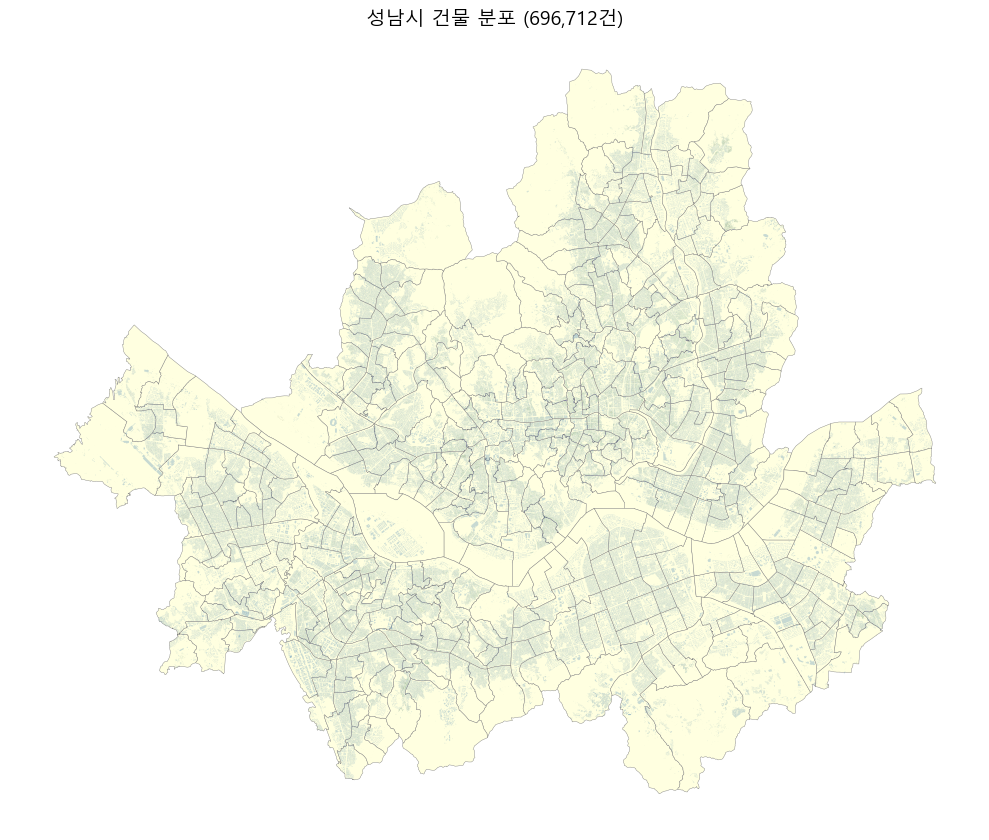

In [6]:
# EPSG:5179 (거리 계산용) 저장
gdf_bldg_seoul.to_file(OUT / "seoul_buildings.gpkg", layer="buildings_5179", driver="GPKG")

# EPSG:4326 (웹 지도/Tableau용) 변환 및 저장
gdf_bldg_4326 = gdf_bldg_seoul.to_crs(epsg=4326)
gdf_bldg_4326.to_file(OUT / "seoul_buildings.gpkg", layer="buildings_4326", driver="GPKG")

print(f"저장 완료: {OUT / 'seoul_buildings.gpkg'}")
print(f"  - buildings_5179: {len(gdf_bldg_seoul):,}건 (EPSG:5179)")
print(f"  - buildings_4326: {len(gdf_bldg_4326):,}건 (EPSG:4326)")

# 건물 밀도 맵 (간단 시각화)
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
seoul_4326 = seoul.to_crs(epsg=4326)
seoul_4326.plot(ax=ax, edgecolor="gray", facecolor="lightyellow", linewidth=0.3)
gdf_bldg_4326.plot(ax=ax, color="steelblue", markersize=0.1, alpha=0.3)
ax.set_title(f"성남시 건물 분포 ({len(gdf_bldg_seoul):,}건)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()